In [39]:
!pip install --upgrade pandas

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## Step-1 - Load the dataset

In [41]:
# read url(The URL must be a string with full slashes)
# url = " httpsarchive.ics.uci.edumlmachine-learning-databasesbalance-scalebalance-scale.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/balance-scale/balance-scale.data"

# Declare the column names(This dataset does not have a header row, so we define column names manually)
col_names = ['Class Name', 'Left-Weight', 'Left-Distance', 'Right-Weight', 'Right-Distance']

#Read the data in the url using read_csv 
data = pd.read_csv(url,header=None,names=col_names)

data = pd.DataFrame(data)
print(data.head())

  Class Name  Left-Weight  Left-Distance  Right-Weight  Right-Distance
0          B            1              1             1               1
1          R            1              1             1               2
2          R            1              1             1               3
3          R            1              1             1               4
4          R            1              1             1               5


In [42]:
print(data.shape)

(625, 5)


In [43]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Class Name      625 non-null    object
 1   Left-Weight     625 non-null    int64 
 2   Left-Distance   625 non-null    int64 
 3   Right-Weight    625 non-null    int64 
 4   Right-Distance  625 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 24.5+ KB
None


## Step 2 – Preprocess the Dataset
 

##### As a next step, let's preprocess the dataset. The features are all on different scales. To bring them all to a common scale, we’ll use the StandardScaler that transforms the features to have zero mean and unit variance:

In [44]:
# 'Class Name' is your target (categorical), so we remove it to get our features
X = data.drop('Class Name', axis=1)

# 'Class Name' is kept separately as y (the target we want to predict or label)
y = data['Class Name']


In [45]:
# from sklearn.preprocessing import StandardScaler
# std_scaler = StandardScaler()
# scaled_df = std_scaler.fit_transform(df)

# Do with the calculation part also

import numpy as np
import pandas as pd

# 1. Calculate the mean (mu) for each column
# Scikit-learn equivalent: scaler.mean_
mu = np.mean(X, axis=0)

# 2. Calculate the population standard deviation (sigma)
# Must use ddof=0 to match Scikit-learn's default behavior
# Scikit-learn equivalent: scaler.scale_
sigma = np.std(X, axis=0, ddof=0)

# 3. Apply the Z-score formula
# This centers the data (mean=0) and scales it (variance=1)
X_scaled_manual = (X - mu) / sigma

# Check the results
print("Manual Scaled Data:\n", X_scaled_manual.head())


Manual Scaled Data:
    Left-Weight  Left-Distance  Right-Weight  Right-Distance
0    -1.414214      -1.414214     -1.414214       -1.414214
1    -1.414214      -1.414214     -1.414214       -0.707107
2    -1.414214      -1.414214     -1.414214        0.000000
3    -1.414214      -1.414214     -1.414214        0.707107
4    -1.414214      -1.414214     -1.414214        1.414214


## Step 3 – Perform PCA on the Preprocessed Dataset

#### To find the principal components, we can use the PCA class from scikit-learn’s decomposition module.

Let’s instantiate a PCA object by passing in the number of principal components n_components to the constructor. 

The number of principal components is the number of dimensions that you’d like to reduce the feature space to. Here, we set the number of components to 3.

In [46]:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=3)
# pca.fit_transform(scaled_df)

import numpy as np
import pandas as pd

# Assume 'scaled_X' is your standardized data from the previous step
# 1. Compute the Covariance Matrix
# This matrix shows how each pair of features varies together.
# 'rowvar=False' tells numpy that columns are features.
cov_matrix = np.cov(X_scaled_manual, rowvar=False)

# 2. Calculate Eigenvalues and Eigenvectors
# Eigenvectors: The directions of the new axes (Principal Components).
# Eigenvalues: The magnitude of variance in those directions.
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 3. Sort Eigenvalues and Eigenvectors in descending order
# We want the components that capture the MOST variance first.
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 4. Select top 'k' components (e.g., n_components=3)
# We take the first 3 columns of the eigenvector matrix.
k = 3
feature_vector = eigenvectors[:, :k]

# 5. Transform the data (Project onto the new axes)
# We use the dot product to rotate the original data points.
pca_manual = np.dot(X_scaled_manual, feature_vector)

# Create a DataFrame for the result
pca_manual_df = pd.DataFrame(pca_manual, columns=['PC1', 'PC2', 'PC3'])


## Step 4 – Examining Some Useful Attributes of the PCA Object

 The PCA instance pca that we created has several useful attributes that help us understand what is going on under the hood.

The attribute components_ stores the directions of maximum variance (the principal components).



In [47]:
# print(pca_manual.components_)

# To match Scikit-learn's .components_ exactly:
components_sklearn_style = feature_vector.T

print("Principal Components (Eigenvectors):")
print(components_sklearn_style)


Principal Components (Eigenvectors):
[[ 3.96080529e-20 -9.66624081e-02 -2.17369913e-02  9.95079837e-01]
 [ 0.00000000e+00 -7.06124391e-01  7.07751874e-01 -2.18089182e-02]
 [-7.07106781e-01 -4.99305345e-01 -4.99305345e-01 -3.72604936e-02]]


In [48]:
# print(sum(pca.explained_variance_ratio_))

print(sum(feature_vector.T))

[-0.70710678 -1.30209214  0.18670954  0.93601043]


## Step 5 – Analyzing the Change in Explained Variance Ratio

We can try running principal component analysis by varying the number of components n_components.

In [49]:
from sklearn.decomposition import PCA
import numpy as np
#nums = np.arange(14)
# Check how many features you actually have
max_features = X_scaled_manual.shape[1] 

# Re-define nums to stay within the limit (1 to max_features)
nums = np.arange(1, max_features + 1) 

In [50]:
var_ratio = []
for num in nums :
    pca = PCA(n_components=num)
    pca.fit(X_scaled_manual)
    var_ratio.append(np.sum(pca.explained_variance_ratio_))

print(f"Variance ratios for 1 to {max_features} components:")
print(var_ratio)

Variance ratios for 1 to 4 components:
[np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]


## To visualize the explained_variance_ratio_ for the number of components, let’s plot the two quantities as shown:

Text(0.5, 1.0, 'n_components vs. Explained variance ratio')

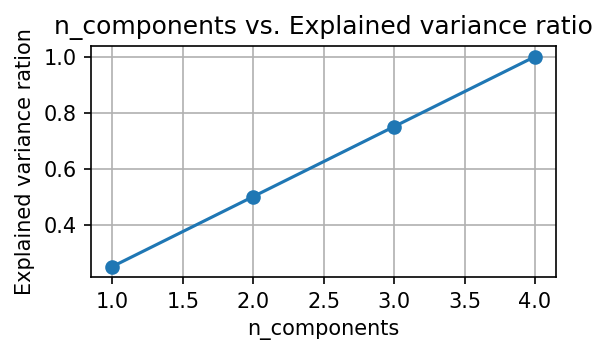

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,2),dpi=150)
plt.grid()
plt.plot(nums,var_ratio,marker='o')
plt.xlabel("n_components")
plt.ylabel('Explained variance ration')
plt.title('n_components vs. Explained variance ratio')

When we use all the 13 components, the explained_variance_ratio_ is 1.0 indicating that we’ve captured 100% of the variance in the dataset. 

In this example, we see that with 6 principal components, we'll be able to capture more than 80% of variance in the input dataset.